In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

In [2]:
def branin(X):
    """
    X: numpy array shape [N, 2]
    Возвращаем -Branin, чтобы задача была на максимум.
    """
    x1 = X[:, 0]
    x2 = X[:, 1]

    a = 1.0
    b = 5.1 / (4.0 * np.pi**2)
    c = 5.0 / np.pi
    r = 6.0
    s = 10.0
    t = 1.0 / (8.0 * np.pi)

    y = a * (x2 - b * x1**2 + c * x1 - r) ** 2 + s * (1 - t) * np.cos(x1) + s
    return -y.astype(np.float32)


lb = np.array([-5.0, 0.0], dtype=np.float32)
ub = np.array([10.0, 15.0], dtype=np.float32)

def sample_uniform(n):
    return lb + (ub - lb) * np.random.rand(n, 2).astype(np.float32)

In [3]:
n_init = 8
X_train = sample_uniform(n_init)
y_train = branin(X_train)

print(X_train.shape, y_train.shape)
print("best init value:", y_train.max())

(8, 2) (8,)
best init value: -7.8791637


In [4]:
class MLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64, dropout_p=0.1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 1)
        self.dropout_p = dropout_p

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=self.dropout_p, training=True)
        x = F.relu(self.fc2(x))
        x = F.dropout(x, p=self.dropout_p, training=True)
        x = self.fc3(x)
        return x.squeeze(-1)

In [5]:
def train_model(model, X, y, epochs=300, lr=1e-3):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        pred = model(X_t)
        loss = ((pred - y_t) ** 2).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return model

In [6]:
@torch.no_grad()
def mc_predict(model, X, n_samples=30):
    X_t = torch.tensor(X, dtype=torch.float32)

    preds = []
    for _ in range(n_samples):
        pred = model(X_t).cpu().numpy()
        preds.append(pred)

    preds = np.stack(preds, axis=0)  # [T, N]
    mean = preds.mean(axis=0)
    std = preds.std(axis=0)
    return mean, std

In [7]:
def ucb(mean, std, beta=2.0):
    return mean + beta * std

In [8]:
def propose_next_point(model, n_candidates=2000, beta=2.0):
    X_cand = sample_uniform(n_candidates)
    mean, std = mc_predict(model, X_cand, n_samples=30)
    acq = ucb(mean, std, beta=beta)
    idx = np.argmax(acq)
    return X_cand[idx:idx+1]

In [9]:
def run_bo(n_init=8, n_iter=25, hidden_dim=64, dropout_p=0.1, beta=2.0):
    X = sample_uniform(n_init)
    y = branin(X)

    best_values = []

    # грубая оценка оптимума для regret
    X_ref = sample_uniform(20000)
    y_ref = branin(X_ref)
    y_opt_approx = y_ref.max()

    regrets = []

    for step in range(n_iter):
        model = MLP(input_dim=2, hidden_dim=hidden_dim, dropout_p=dropout_p)
        model = train_model(model, X, y, epochs=300, lr=1e-3)

        X_next = propose_next_point(model, n_candidates=2000, beta=beta)
        y_next = branin(X_next)

        X = np.concatenate([X, X_next], axis=0)
        y = np.concatenate([y, y_next], axis=0)

        best_so_far = y.max()
        regret = y_opt_approx - best_so_far

        best_values.append(best_so_far)
        regrets.append(regret)

        print(f"iter={step+1}, y_next={y_next[0]:.4f}, best={best_so_far:.4f}, regret={regret:.4f}")

    return X, y, best_values, regrets

iter=1, y_next=-260.2332, best=-4.0823, regret=3.6830
iter=2, y_next=-3.0377, best=-3.0377, regret=2.6384
iter=3, y_next=-2.4351, best=-2.4351, regret=2.0358
iter=4, y_next=-6.5863, best=-2.4351, regret=2.0358
iter=5, y_next=-10.6093, best=-2.4351, regret=2.0358
iter=6, y_next=-1.3144, best=-1.3144, regret=0.9151
iter=7, y_next=-6.7700, best=-1.3144, regret=0.9151
iter=8, y_next=-7.5674, best=-1.3144, regret=0.9151
iter=9, y_next=-0.5275, best=-0.5275, regret=0.1282
iter=10, y_next=-5.1820, best=-0.5275, regret=0.1282
iter=11, y_next=-5.1800, best=-0.5275, regret=0.1282
iter=12, y_next=-0.7578, best=-0.5275, regret=0.1282
iter=13, y_next=-13.4002, best=-0.5275, regret=0.1282
iter=14, y_next=-6.0165, best=-0.5275, regret=0.1282
iter=15, y_next=-0.4433, best=-0.4433, regret=0.0440
iter=16, y_next=-19.5675, best=-0.4433, regret=0.0440
iter=17, y_next=-7.6041, best=-0.4433, regret=0.0440
iter=18, y_next=-0.6095, best=-0.4433, regret=0.0440
iter=19, y_next=-3.9235, best=-0.4433, regret=0.04

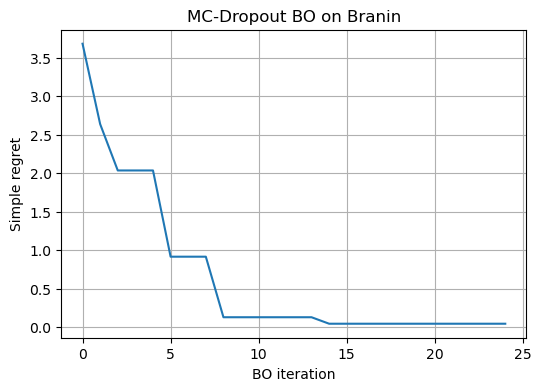

In [10]:
X, y, best_values, regrets = run_bo()

plt.figure(figsize=(6,4))
plt.plot(regrets)
plt.xlabel("BO iteration")
plt.ylabel("Simple regret")
plt.title("MC-Dropout BO on Branin")
plt.grid(True)
plt.show()

Baseline neural Bayesian optimization with MC-Dropout successfully reduces simple regret on Branin and reaches a near-optimal solution within about 10–15 BO iterations.

Реализация baseline MC-Dropout Bayesian Optimization на функции Branin работает корректно: regret монотонно снижается ступенчато, а лучшее найденное значение быстро приближается к глобальному максимуму. Метод уже достигает near-optimal quality примерно за 10–15 итераций, что делает его хорошей отправной точкой для дальнейшего сравнения с GFlowNet-guided mask sampling.


In [11]:
# Истинный максимум для нашей постановки:
# мы максимизируем -Branin, а значит optimum = -0.39788735772973816
BRANIN_TRUE_MAX = -0.39788735772973816


def run_bo_mc_dropout(
    seed=42,
    n_init=8,
    n_iter=25,
    hidden_dim=64,
    dropout_p=0.1,
    beta=2.0,
    epochs=300,
    lr=1e-3,
):
    np.random.seed(seed)
    torch.manual_seed(seed)

    X = sample_uniform(n_init)
    y = branin(X)

    best_values = []
    regrets = []

    best_idx = np.argmax(y)
    best_x = X[best_idx].copy()
    best_y = float(y[best_idx])

    for step in range(n_iter):
        model = MLP(input_dim=2, hidden_dim=hidden_dim, dropout_p=dropout_p)
        model = train_model(model, X, y, epochs=epochs, lr=lr)

        X_next = propose_next_point(model, n_candidates=2000, beta=beta)
        y_next = branin(X_next)

        X = np.concatenate([X, X_next], axis=0)
        y = np.concatenate([y, y_next], axis=0)

        cur_best_idx = np.argmax(y)
        cur_best_y = float(y[cur_best_idx])

        if cur_best_y > best_y:
            best_y = cur_best_y
            best_x = X[cur_best_idx].copy()

        regret = BRANIN_TRUE_MAX - best_y

        best_values.append(best_y)
        regrets.append(regret)

        print(
            f"[MC seed={seed}] iter={step+1:02d}, "
            f"y_next={float(y_next[0]):.4f}, best={best_y:.4f}, regret={regret:.6f}"
        )

    return {
        "X": X,
        "y": y,
        "best_x": best_x,
        "best_y": best_y,
        "best_values": np.array(best_values),
        "regrets": np.array(regrets),
    }

In [12]:
def run_random_search(
    seed=42,
    n_init=8,
    n_iter=25,
):
    np.random.seed(seed)
    torch.manual_seed(seed)

    X = sample_uniform(n_init)
    y = branin(X)

    best_values = []
    regrets = []

    best_idx = np.argmax(y)
    best_x = X[best_idx].copy()
    best_y = float(y[best_idx])

    for step in range(n_iter):
        X_next = sample_uniform(1)
        y_next = branin(X_next)

        X = np.concatenate([X, X_next], axis=0)
        y = np.concatenate([y, y_next], axis=0)

        cur_best_idx = np.argmax(y)
        cur_best_y = float(y[cur_best_idx])

        if cur_best_y > best_y:
            best_y = cur_best_y
            best_x = X[cur_best_idx].copy()

        regret = BRANIN_TRUE_MAX - best_y

        best_values.append(best_y)
        regrets.append(regret)

        print(
            f"[RAND seed={seed}] iter={step+1:02d}, "
            f"y_next={float(y_next[0]):.4f}, best={best_y:.4f}, regret={regret:.6f}"
        )

    return {
        "X": X,
        "y": y,
        "best_x": best_x,
        "best_y": best_y,
        "best_values": np.array(best_values),
        "regrets": np.array(regrets),
    }

In [15]:
def run_many_seeds(
    seeds,
    method="mc_dropout",
    n_init=8,
    n_iter=25,
    hidden_dim=64,
    dropout_p=0.1,
    beta=2.0,
    epochs=300,
    lr=1e-3,
):
    all_regrets = []
    all_best_values = []
    all_best_y = []
    all_best_x = []

    for seed in seeds:
        if method == "mc_dropout":
            result = run_bo_mc_dropout(
                seed=seed,
                n_init=n_init,
                n_iter=n_iter,
                hidden_dim=hidden_dim,
                dropout_p=dropout_p,
                beta=beta,
                epochs=epochs,
                lr=lr,
            )
        elif method == "random":
            result = run_random_search(
                seed=seed,
                n_init=n_init,
                n_iter=n_iter,
            )
        else:
            raise ValueError("method must be 'mc_dropout' or 'random'")

        all_regrets.append(result["regrets"])
        all_best_values.append(result["best_values"])
        all_best_y.append(result["best_y"])
        all_best_x.append(result["best_x"])

    all_regrets = np.stack(all_regrets, axis=0)      # [S, T]
    all_best_values = np.stack(all_best_values, axis=0)

    summary = {
        "method": method,
        "seeds": list(seeds),
        "all_regrets": all_regrets,
        "all_best_values": all_best_values,
        "mean_regret": all_regrets.mean(axis=0),
        "std_regret": all_regrets.std(axis=0),
        "mean_best_value": all_best_values.mean(axis=0),
        "std_best_value": all_best_values.std(axis=0),
        "final_best_y_per_seed": np.array(all_best_y),
        "best_x_per_seed": np.stack(all_best_x, axis=0),
    }
    return summary

In [16]:
def plot_regret_comparison(mc_summary, rand_summary):
    x = np.arange(1, len(mc_summary["mean_regret"]) + 1)

    plt.figure(figsize=(8, 5))

    plt.plot(x, mc_summary["mean_regret"], label="MC-Dropout BO")
    plt.fill_between(
        x,
        mc_summary["mean_regret"] - mc_summary["std_regret"],
        mc_summary["mean_regret"] + mc_summary["std_regret"],
        alpha=0.2,
    )

    plt.plot(x, rand_summary["mean_regret"], label="Random Search")
    plt.fill_between(
        x,
        rand_summary["mean_regret"] - rand_summary["std_regret"],
        rand_summary["mean_regret"] + rand_summary["std_regret"],
        alpha=0.2,
    )

    plt.xlabel("BO iteration")
    plt.ylabel("Simple regret")
    plt.title("Branin: mean ± std over seeds")
    plt.grid(True)
    plt.legend()
    plt.show()

[MC seed=0] iter=01, y_next=-4.2191, best=-4.2191, regret=3.821172
[MC seed=0] iter=02, y_next=-6.1334, best=-4.2191, regret=3.821172
[MC seed=0] iter=03, y_next=-4.4531, best=-4.2191, regret=3.821172
[MC seed=0] iter=04, y_next=-5.7114, best=-4.2191, regret=3.821172
[MC seed=0] iter=05, y_next=-3.6439, best=-3.6439, regret=3.246043
[MC seed=0] iter=06, y_next=-4.8111, best=-3.6439, regret=3.246043
[MC seed=0] iter=07, y_next=-10.4370, best=-3.6439, regret=3.246043
[MC seed=0] iter=08, y_next=-5.0194, best=-3.6439, regret=3.246043
[MC seed=0] iter=09, y_next=-15.5032, best=-3.6439, regret=3.246043
[MC seed=0] iter=10, y_next=-5.7251, best=-3.6439, regret=3.246043
[MC seed=0] iter=11, y_next=-18.1243, best=-3.6439, regret=3.246043
[MC seed=0] iter=12, y_next=-11.4565, best=-3.6439, regret=3.246043
[MC seed=0] iter=13, y_next=-10.1186, best=-3.6439, regret=3.246043
[MC seed=0] iter=14, y_next=-21.6058, best=-3.6439, regret=3.246043
[MC seed=0] iter=15, y_next=-20.3468, best=-3.6439, regr

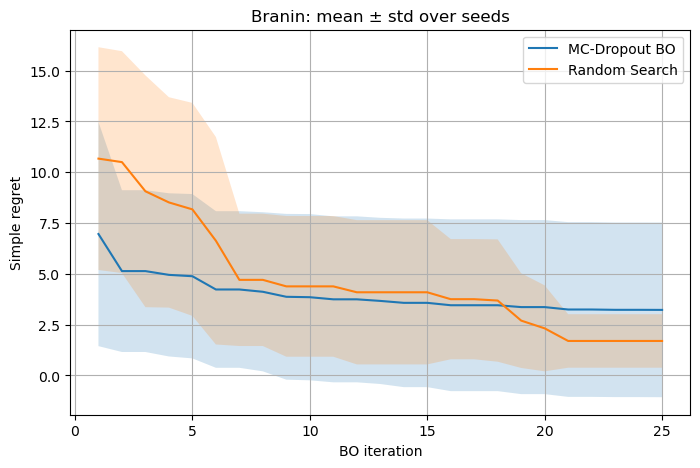

In [17]:
seeds = list(range(10))

mc_summary = run_many_seeds(
    seeds=seeds,
    method="mc_dropout",
    n_init=8,
    n_iter=25,
    hidden_dim=64,
    dropout_p=0.1,
    beta=2.0,
    epochs=300,
    lr=1e-3,
)

rand_summary = run_many_seeds(
    seeds=seeds,
    method="random",
    n_init=8,
    n_iter=25,
)

plot_regret_comparison(mc_summary, rand_summary)

In [18]:
print("=== Final regret over seeds ===")
print(f"MC-Dropout BO: mean={mc_summary['all_regrets'][:, -1].mean():.6f}, std={mc_summary['all_regrets'][:, -1].std():.6f}")
print(f"Random Search: mean={rand_summary['all_regrets'][:, -1].mean():.6f}, std={rand_summary['all_regrets'][:, -1].std():.6f}")

print("\n=== Final best value over seeds ===")
print(f"MC-Dropout BO: mean={mc_summary['final_best_y_per_seed'].mean():.6f}, std={mc_summary['final_best_y_per_seed'].std():.6f}")
print(f"Random Search: mean={rand_summary['final_best_y_per_seed'].mean():.6f}, std={rand_summary['final_best_y_per_seed'].std():.6f}")
print(f"True optimum: {BRANIN_TRUE_MAX:.6f}")

=== Final regret over seeds ===
MC-Dropout BO: mean=3.224370, std=4.298091
Random Search: mean=1.695472, std=1.317093

=== Final best value over seeds ===
MC-Dropout BO: mean=-3.622257, std=4.298091
Random Search: mean=-2.093359, std=1.317093
True optimum: -0.397887


In [19]:
best_seed_idx = np.argmax(mc_summary["final_best_y_per_seed"])
best_seed = mc_summary["seeds"][best_seed_idx]
best_x = mc_summary["best_x_per_seed"][best_seed_idx]
best_y = mc_summary["final_best_y_per_seed"][best_seed_idx]

print("Best MC-Dropout run")
print("seed:", best_seed)
print("best_x:", best_x)
print("best_y:", best_y)
print("true optimum:", BRANIN_TRUE_MAX)
print("final regret:", BRANIN_TRUE_MAX - best_y)

Best MC-Dropout run
seed: 9
best_x: [9.514379  2.8165631]
best_y: -0.5066013336181641
true optimum: -0.39788735772973816
final regret: 0.1087139758884259


# GFlowNet

In [20]:
hidden_dim = 64
block_size = 8

assert hidden_dim % block_size == 0

n_blocks_per_layer = hidden_dim // block_size   # 8
total_blocks = 2 * n_blocks_per_layer           # 16


def split_mask_bits(mask_bits, n_blocks_per_layer=n_blocks_per_layer, block_size=block_size):
    """
    mask_bits: array shape [total_blocks], values in {0,1}
    returns full masks for layer1 and layer2, shape [hidden_dim]
    """
    mask_bits = np.asarray(mask_bits).astype(np.float32)

    bits1 = mask_bits[:n_blocks_per_layer]
    bits2 = mask_bits[n_blocks_per_layer:]

    full1 = np.repeat(bits1, block_size).astype(np.float32)
    full2 = np.repeat(bits2, block_size).astype(np.float32)
    return full1, full2


def sample_random_mask_bits():
    """
    Random block-wise mask with the constraint:
    at least one block must be kept in each layer.
    """
    bits1 = np.random.binomial(1, 0.5, size=n_blocks_per_layer).astype(np.float32)
    bits2 = np.random.binomial(1, 0.5, size=n_blocks_per_layer).astype(np.float32)

    if bits1.sum() == 0:
        bits1[np.random.randint(n_blocks_per_layer)] = 1.0
    if bits2.sum() == 0:
        bits2[np.random.randint(n_blocks_per_layer)] = 1.0

    return np.concatenate([bits1, bits2], axis=0)

In [21]:
class MaskedMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64, dropout_p=0.1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 1)
        self.dropout_p = dropout_p
        self.hidden_dim = hidden_dim

    def forward(self, x, masks=None):
        """
        x: [B, 2]
        masks:
            None -> обычный random dropout
            [m1, m2] -> внешние masks
                m1 shape [hidden_dim] or [1, hidden_dim]
                m2 shape [hidden_dim] or [1, hidden_dim]
        """
        h = F.relu(self.fc1(x))

        if masks is None:
            h = F.dropout(h, p=self.dropout_p, training=True)
        else:
            m1, m2 = masks
            if m1.ndim == 1:
                m1 = m1.unsqueeze(0)
            h = h * m1

        h = F.relu(self.fc2(h))

        if masks is None:
            h = F.dropout(h, p=self.dropout_p, training=True)
        else:
            if m2.ndim == 1:
                m2 = m2.unsqueeze(0)
            h = h * m2

        out = self.fc3(h)
        return out.squeeze(-1)

In [22]:
def train_masked_model(model, X, y, epochs=300, lr=1e-3):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(epochs):
        pred = model(X_t, masks=None)   # training with random dropout
        loss = ((pred - y_t) ** 2).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return model

In [23]:
np.random.seed(42)
torch.manual_seed(42)

X_current = sample_uniform(12)
y_current = branin(X_current)

masked_model = MaskedMLP(input_dim=2, hidden_dim=hidden_dim, dropout_p=0.1)
masked_model = train_masked_model(masked_model, X_current, y_current, epochs=400, lr=1e-3)

y_best_current = float(y_current.max())
print("Current best y:", y_best_current)

Current best y: -5.344757080078125


In [24]:
@torch.no_grad()
def proxy_reward_for_mask(
    model,
    mask_bits,
    y_best,
    n_candidates=512,
    reward_temperature=1.0,
):
    """
    Returns:
        reward: positive scalar
        x_best: best candidate under this mask
        best_pred: masked surrogate prediction at x_best
        improvement: best_pred - y_best
    """
    full1, full2 = split_mask_bits(mask_bits)

    m1 = torch.tensor(full1, dtype=torch.float32).unsqueeze(0)
    m2 = torch.tensor(full2, dtype=torch.float32).unsqueeze(0)

    X_cand = sample_uniform(n_candidates)
    X_t = torch.tensor(X_cand, dtype=torch.float32)

    preds = model(X_t, masks=[m1, m2]).cpu().numpy()
    idx = np.argmax(preds)

    x_best = X_cand[idx:idx+1]
    best_pred = float(preds[idx])
    improvement = best_pred - float(y_best)

    # Делаем reward строго положительным для log R в GFlowNet
    reward = float(F.softplus(torch.tensor(improvement / reward_temperature)).item() + 1e-4)

    return reward, x_best, best_pred, improvement

In [25]:
random_rewards = []
random_improvements = []

for _ in range(100):
    bits = sample_random_mask_bits()
    reward, x_best, best_pred, improvement = proxy_reward_for_mask(
        masked_model,
        bits,
        y_best_current,
        n_candidates=512,
    )
    random_rewards.append(reward)
    random_improvements.append(improvement)

print("Random masks:")
print("mean reward:", np.mean(random_rewards))
print("std reward :", np.std(random_rewards))
print("max reward :", np.max(random_rewards))
print("mean improvement:", np.mean(random_improvements))
print("max improvement :", np.max(random_improvements))

Random masks:
mean reward: 5.676841101741791
std reward : 0.880064905021042
max reward : 8.29674134979248
mean improvement: 5.672014307366917
max improvement : 8.29639220237732


In [26]:
class MaskGFlowNet(nn.Module):
    def __init__(self, total_blocks, hidden_size=128):
        super().__init__()
        self.total_blocks = total_blocks

        # input = partial mask + step index + y_best context
        self.net = nn.Sequential(
            nn.Linear(total_blocks + 2, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1),   # Bernoulli logit for "keep block"
        )

        self.logZ = nn.Parameter(torch.tensor(0.0))

    def forward_logit(self, partial_mask, step_idx, y_context):
        """
        partial_mask: [1, total_blocks], values in {-1,0,1}
        step_idx: scalar in [0, total_blocks-1]
        y_context: scalar
        """
        step_feat = torch.tensor([[step_idx / self.total_blocks]], dtype=torch.float32)
        ctx_feat = torch.tensor([[y_context]], dtype=torch.float32)
        inp = torch.cat([partial_mask, step_feat, ctx_feat], dim=1)
        logit = self.net(inp)
        return logit.squeeze(0).squeeze(0)

    def sample_trajectory(self, y_context=0.0, greedy=False):
        """
        Returns:
            mask_bits: numpy array shape [total_blocks]
            log_pf: tensor scalar = sum log forward probabilities
        """
        state = torch.full((1, self.total_blocks), -1.0, dtype=torch.float32)
        chosen = []
        log_pf_terms = []

        for step in range(self.total_blocks):
            # constraint: at least one block per layer must be kept
            force_keep = False

            if step == n_blocks_per_layer - 1:
                first_layer_so_far = chosen[:step]
                if sum(first_layer_so_far) == 0:
                    force_keep = True

            if step == self.total_blocks - 1:
                second_layer_so_far = chosen[n_blocks_per_layer:step]
                if sum(second_layer_so_far) == 0:
                    force_keep = True

            if force_keep:
                action = 1.0
            else:
                logit = self.forward_logit(state, step, y_context)
                prob = torch.sigmoid(logit)

                if greedy:
                    action = float((prob >= 0.5).item())
                else:
                    action = float(torch.bernoulli(prob).item())

                logp = torch.log(prob + 1e-8) if action == 1.0 else torch.log(1.0 - prob + 1e-8)
                log_pf_terms.append(logp)

            chosen.append(action)
            state[0, step] = action

        if len(log_pf_terms) == 0:
            log_pf = torch.tensor(0.0)
        else:
            log_pf = torch.stack(log_pf_terms).sum()

        mask_bits = np.array(chosen, dtype=np.float32)
        return mask_bits, log_pf

In [27]:
def train_gflownet_on_surrogate(
    model,
    y_best,
    total_blocks,
    n_steps=300,
    batch_size=32,
    n_candidates=512,
    lr=1e-3,
):
    gfn = MaskGFlowNet(total_blocks=total_blocks, hidden_size=128)
    optimizer = torch.optim.Adam(gfn.parameters(), lr=lr)

    losses = []
    mean_rewards = []

    for step in range(n_steps):
        batch_log_pf = []
        batch_log_r = []
        batch_rewards = []

        for _ in range(batch_size):
            mask_bits, log_pf = gfn.sample_trajectory(y_context=float(y_best), greedy=False)

            reward, _, _, _ = proxy_reward_for_mask(
                model,
                mask_bits,
                y_best,
                n_candidates=n_candidates,
            )

            batch_log_pf.append(log_pf)
            batch_log_r.append(torch.log(torch.tensor(reward, dtype=torch.float32)))
            batch_rewards.append(reward)

        batch_log_pf = torch.stack(batch_log_pf)
        batch_log_r = torch.stack(batch_log_r)

        loss = ((gfn.logZ + batch_log_pf - batch_log_r) ** 2).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(float(loss.item()))
        mean_rewards.append(float(np.mean(batch_rewards)))

        if (step + 1) % 50 == 0:
            print(
                f"GFN step {step+1:03d}/{n_steps} | "
                f"loss={loss.item():.4f} | "
                f"mean reward={np.mean(batch_rewards):.4f} | "
                f"logZ={gfn.logZ.item():.4f}"
            )

    return gfn, losses, mean_rewards

In [28]:
gfn, gfn_losses, gfn_mean_rewards = train_gflownet_on_surrogate(
    model=masked_model,
    y_best=y_best_current,
    total_blocks=total_blocks,
    n_steps=300,
    batch_size=32,
    n_candidates=512,
    lr=1e-3,
)

GFN step 050/300 | loss=159.4988 | mean reward=5.4132 | logZ=0.0503
GFN step 100/300 | loss=153.3809 | mean reward=5.1973 | logZ=0.1007
GFN step 150/300 | loss=157.6350 | mean reward=5.4481 | logZ=0.1509
GFN step 200/300 | loss=159.6164 | mean reward=5.7914 | logZ=0.2008
GFN step 250/300 | loss=158.4431 | mean reward=5.6471 | logZ=0.2507
GFN step 300/300 | loss=156.1350 | mean reward=5.6963 | logZ=0.3001


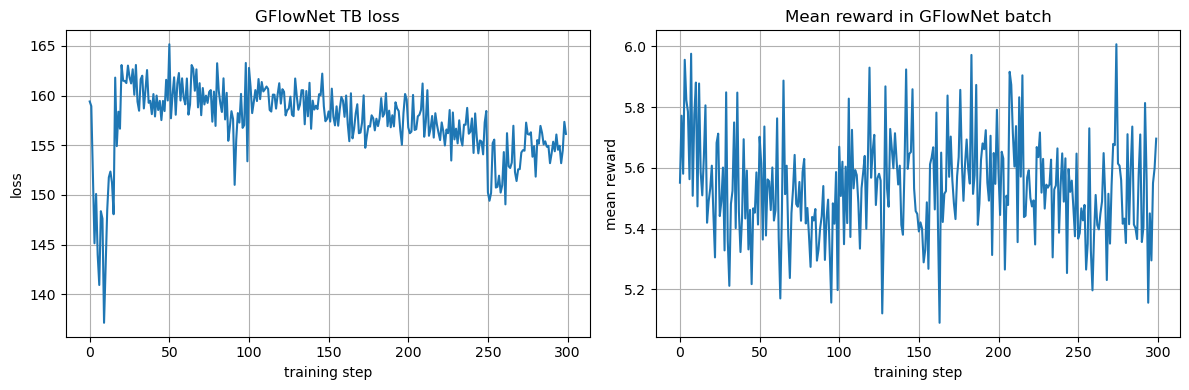

In [29]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(gfn_losses)
plt.title("GFlowNet TB loss")
plt.xlabel("training step")
plt.ylabel("loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(gfn_mean_rewards)
plt.title("Mean reward in GFlowNet batch")
plt.xlabel("training step")
plt.ylabel("mean reward")
plt.grid(True)

plt.tight_layout()
plt.show()

In [30]:
@torch.no_grad()
def evaluate_mask_sampler(
    model,
    y_best,
    sampler="random",
    gfn=None,
    n_masks=100,
    n_candidates=512,
):
    rewards = []
    improvements = []
    preds = []

    for _ in range(n_masks):
        if sampler == "random":
            mask_bits = sample_random_mask_bits()
        elif sampler == "gfn":
            mask_bits, _ = gfn.sample_trajectory(y_context=float(y_best), greedy=False)
        else:
            raise ValueError("sampler must be 'random' or 'gfn'")

        reward, x_best, best_pred, improvement = proxy_reward_for_mask(
            model,
            mask_bits,
            y_best,
            n_candidates=n_candidates,
        )
        rewards.append(reward)
        improvements.append(improvement)
        preds.append(best_pred)

    return {
        "rewards": np.array(rewards),
        "improvements": np.array(improvements),
        "preds": np.array(preds),
    }


random_eval = evaluate_mask_sampler(
    masked_model,
    y_best_current,
    sampler="random",
    n_masks=100,
    n_candidates=512,
)

gfn_eval = evaluate_mask_sampler(
    masked_model,
    y_best_current,
    sampler="gfn",
    gfn=gfn,
    n_masks=100,
    n_candidates=512,
)

print("Random mean reward:", random_eval["rewards"].mean())
print("GFN mean reward   :", gfn_eval["rewards"].mean())
print("Random max reward :", random_eval["rewards"].max())
print("GFN max reward    :", gfn_eval["rewards"].max())

Random mean reward: 5.4244484282493595
GFN mean reward   : 5.426672346687317
Random max reward : 8.014686448669433
GFN max reward    : 8.354458673095703


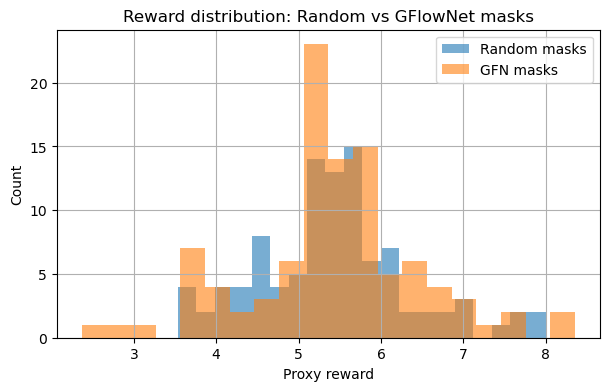

In [31]:
plt.figure(figsize=(7, 4))
plt.hist(random_eval["rewards"], bins=20, alpha=0.6, label="Random masks")
plt.hist(gfn_eval["rewards"], bins=20, alpha=0.6, label="GFN masks")
plt.xlabel("Proxy reward")
plt.ylabel("Count")
plt.title("Reward distribution: Random vs GFlowNet masks")
plt.legend()
plt.grid(True)
plt.show()

In [32]:
@torch.no_grad()
def propose_next_point_gfn(
    model,
    gfn,
    y_best,
    n_mask_samples=128,
    n_candidates=512,
):
    best_reward = -1e9
    best_x = None
    best_mask = None
    best_pred = None
    best_improvement = None

    for _ in range(n_mask_samples):
        mask_bits, _ = gfn.sample_trajectory(y_context=float(y_best), greedy=False)

        reward, x_best, best_pred_local, improvement_local = proxy_reward_for_mask(
            model,
            mask_bits,
            y_best,
            n_candidates=n_candidates,
        )

        if reward > best_reward:
            best_reward = reward
            best_x = x_best.copy()
            best_mask = mask_bits.copy()
            best_pred = best_pred_local
            best_improvement = improvement_local

    return {
        "x_next": best_x,
        "mask_bits": best_mask,
        "reward": best_reward,
        "best_pred": best_pred,
        "improvement": best_improvement,
    }


proposal = propose_next_point_gfn(
    masked_model,
    gfn,
    y_best_current,
    n_mask_samples=128,
    n_candidates=512,
)

print("Proposed x_next:", proposal["x_next"])
print("Proxy reward   :", proposal["reward"])
print("Predicted value:", proposal["best_pred"])
print("Improvement    :", proposal["improvement"])

Proposed x_next: [[9.861421  0.3276507]]
Proxy reward   : 8.400238854980469
Predicted value: 3.055156707763672
Improvement    : 8.399913787841797


In [33]:
y_true_proposal = branin(proposal["x_next"])[0]
print("Proposed x_next:", proposal["x_next"])
print("Predicted value:", proposal["best_pred"])
print("True oracle value:", y_true_proposal)
print("True improvement:", y_true_proposal - y_best_current)

Proposed x_next: [[9.861421  0.3276507]]
Predicted value: 3.055156707763672
True oracle value: -7.7519016
True improvement: -2.4071445


In [34]:
improvement_clipped = np.clip(improvement, -2.0, 2.0)
reward = float(np.exp(improvement_clipped))